# AST V2 Classification: Full-Track Input

This notebook trains and evaluates the second Audio Spectrogram Transformer variant using full-track audio inputs.

Compared to AST V1, this variant uses an adapted training setup and model head. The model is evaluated on the test set after fine-tuning.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import os
import torch
import random
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from transformers import AutoProcessor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
from transformers import ASTModel, ASTPreTrainedModel, ASTConfig
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score
from src.config import (
    AST_AUDIO_DIR,
    AST_METADATA_CSV,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)


In [ ]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================

# Paths
DATA_DIR = str(AST_AUDIO_DIR)
CSV_FILE = str(AST_METADATA_CSV)
MODEL = "MIT/ast-finetuned-audioset-16-16-0.442"
MODEL_NAME = "AST_V2"

# Training
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
UNFREEZE_EPOCH = 3          # Epoch at which we unfreeze last 2 transformer layers
NUM_UNFROZEN_LAYERS = 6     # Number of transformer layers to unfreeze at UNFREEZE_EPOCH
ACCUMULATION_STEPS = 4      # Gradient accumulation steps
CROP_SECONDS = 15        # Number of seconds to crop from each audio sample (for training)

# Audio
MAX_AUDIO_LENGTH = 30   # Max audio length in seconds
SAMPLING_RATE = 16000   # Target sampling rate

# Filtering
TOP_K_GENRES = 8  # Only keep top K frequent genres (None = all)
EXCLUDE_GENRES = ['International', 'Instrumental', 'Experimental', 'Spoken', 'Country']  # List of genres to exclude
SAMPLES_PER_GENRE = 533  # Max number of samples per genre (None = all)

# Split ratios
VAL_SPLIT_RATIO = 0.1
TEST_SPLIT_RATIO = 0.1

# Random seeds for reproducibility
SEED = RANDOM_STATE
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE=="cuda":
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# ----------- LOAD CSV AND FILTER EXISTING FILES ----------- #
df = pd.read_csv(CSV_FILE, dtype={'track_id': str, 'track_genre_top': str})

# Ensure track_id always has 6 digits
df['filename'] = df['track_id'].str.zfill(6) + ".wav"

# Keep only files that exist on disk
existing_files = set(os.listdir(DATA_DIR))
df_filtered = df[df['filename'].isin(existing_files)].reset_index(drop=True)

print(f"Files in CSV: {len(df)}")
print(f"Files found on disk: {len(df_filtered)}")


# ----------- EXCLUDE GENRES AND SELECT TOP K ----------- #

# Remove unwanted genres
if EXCLUDE_GENRES:
    df_filtered = df_filtered[~df_filtered['track_genre_top'].isin(EXCLUDE_GENRES)]
    print(f"Excluded genres: {EXCLUDE_GENRES}")
    print(f"Remaining files: {len(df_filtered)}")

# Select top K most frequent genres
if TOP_K_GENRES is not None:

    genre_counts = df_filtered['track_genre_top'].value_counts()

    top_genres = genre_counts.head(TOP_K_GENRES).index.tolist()

    df_filtered = df_filtered[df_filtered['track_genre_top'].isin(top_genres)]

    print(f"\n--- Filtering Top {TOP_K_GENRES} Genres ---")
    print(f"Remaining genres: {top_genres}")
    print(f"Files after filter: {len(df_filtered)}")


# ----------- BALANCING AND DATA SPLIT ----------- #

train_val_rows, test_rows = [], []
train_rows, val_rows = [], []

grouped = df_filtered.groupby("track_genre_top")

print("\n--- Balancing & Splitting ---")

for genre, group in grouped:

    n_available = len(group)

    # Limit samples per genre if configured
    if SAMPLES_PER_GENRE is not None and n_available > SAMPLES_PER_GENRE:
        group_subset = group.sample(n=SAMPLES_PER_GENRE, random_state=RANDOM_STATE)
        print(f"Genre '{genre}': reduced to {SAMPLES_PER_GENRE}")
    else:
        group_subset = group
        print(f"Genre '{genre}': using {n_available} samples")

    # Split test set
    test_size_n = max(1, int(len(group_subset) * TEST_SPLIT_RATIO))

    train_val_group, test_group = train_test_split(
        group_subset,
        test_size=test_size_n,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    test_rows.append(test_group)

    # Split validation set
    val_size_n = max(1, int(len(group_subset) * VAL_SPLIT_RATIO))

    train_group, val_group = train_test_split(
        train_val_group,
        test_size=val_size_n,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    train_rows.append(train_group)
    val_rows.append(val_group)


# Combine final dataframes
train_df = pd.concat(train_rows).reset_index(drop=True)
val_df = pd.concat(val_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True)


# ----------- LABEL ENCODER ----------- #
le = LabelEncoder()
le.fit(train_df['track_genre_top'])

print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Files in CSV: 106574
Files found on disk: 103871
Excluded genres: ['International', 'Instrumental', 'Experimental', 'Spoken', 'Country']
Remaining files: 89636

--- Filtering Top 8 Genres ---
Remaining genres: ['Rock', 'Electronic', 'Hip-Hop', 'Folk', 'Pop', 'Classical', 'Jazz', 'Old-Time / Historic']
Files after filter: 33606

--- Balancing & Splitting ---
Genre 'Classical': reduced to 533
Genre 'Electronic': reduced to 533
Genre 'Folk': reduced to 533
Genre 'Hip-Hop': reduced to 533
Genre 'Jazz': reduced to 533
Genre 'Old-Time / Historic': reduced to 533
Genre 'Pop': reduced to 533
Genre 'Rock': reduced to 533
Class mapping: {'Classical': np.int64(0), 'Electronic': np.int64(1), 'Folk': np.int64(2), 'Hip-Hop': np.int64(3), 'Jazz': np.int64(4), 'Old-Time / Historic': np.int64(5), 'Pop': np.int64(6), 'Rock': np.int64(7)}


In [20]:
# -------------------------------
# SpecAugment: Frequency & Time Masking
# -------------------------------

# Randomly mask frequency bands (max 30 bins) and time segments (max 100 frames)
freq_masking = T.FrequencyMasking(freq_mask_param=24)
time_masking = T.TimeMasking(time_mask_param=60)

def apply_spec_augment(spec):
    if spec.dim() == 2:
        spec = spec.unsqueeze(0)
        squeeze_back = True
    else:
        squeeze_back = False

    spec = freq_masking(spec)
    spec = time_masking(spec)

    if squeeze_back:
        spec = spec.squeeze(0)
    return spec

In [21]:
class CSVDataset(Dataset):
    """
    PyTorch dataset for audio files and labels.
    Handles loading, padding, mono conversion, resampling, and processor preparation.
    """
    def __init__(self, df, root_dir, processor, max_length=MAX_AUDIO_LENGTH, le=None, split="train"):
        # Store audio processor
        self.processor = processor

        # Maximum audio length in seconds
        self.max_length = max_length

        # Root directory where audio files are stored
        self.root_dir = root_dir

        # Make a copy of the dataframe to avoid modifying the original
        self.df = df.copy()

        # LabelEncoder instance (used to convert string labels → integer labels)
        self.le = le


        self.split = split

        # Convert genre names to integer labels
        self.df['label'] = self.le.transform(self.df['track_genre_top'])

    def __len__(self):
        # Return total number of samples in the dataset
        return len(self.df)

    def __getitem__(self, idx):
        # Get one sample by index
        row = self.df.iloc[idx]

        # Construct full file path
        file_path = os.path.join(self.root_dir, str(row['filename']))

        # Get integer label
        label = int(row['label'])

        try:
            # Load audio file
            waveform_np, sr = sf.read(file_path, dtype="float32")

            # If audio is mono, add channel dimension
            if waveform_np.ndim == 1:
                waveform_np = np.expand_dims(waveform_np, axis=0)

            # If shape is (samples, channels), transpose to (channels, samples)
            elif waveform_np.ndim == 2 and waveform_np.shape[0] > waveform_np.shape[1]:
                waveform_np = waveform_np.T

        except Exception as e:
            # If loading fails, use zero tensor as fallback
            print(f"Error loading {file_path}: {e}")
            waveform_np = np.zeros((1, 16000 * self.max_length), dtype="float32")
            sr = 16000

        # Convert NumPy array to PyTorch tensor
        waveform = torch.tensor(waveform_np, dtype=torch.float32)

        # Resample to 16 kHz if needed
        if sr != 16000:
            waveform = torch.nn.functional.interpolate(
                waveform.unsqueeze(0),
                size=int(16000 * waveform.shape[1] / sr),
                mode="linear",
                align_corners=False
            ).squeeze(0)

        # Convert stereo to mono by averaging channels
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Ensure fixed audio length (cut or pad)
        target_len = 16000 * CROP_SECONDS
        if waveform.shape[1] > target_len:
            start = np.random.randint(0, waveform.shape[1] - target_len + 1) if self.split == "train" else 0
            waveform = waveform[:, start:start + target_len]

        elif waveform.shape[1] < target_len:
            waveform = F.pad(waveform, (0, target_len - waveform.shape[1]))

        # Convert tensor back to NumPy for processor
        waveform_final_np = waveform.squeeze().numpy()

       # Extract model inputs using the feature processor
        inputs = self.processor(
            waveform_final_np,
            sampling_rate=SAMPLING_RATE,
            return_tensors="pt"
        )

        input_values = inputs["input_values"].squeeze(0)

        if self.split == "train":
            input_values = apply_spec_augment(input_values)

        return input_values, torch.tensor(label, dtype=torch.long), row["track_id"]

In [22]:
# ============================================================
# CUSTOM AST CLASSIFIER
# ============================================================

class CustomASTClassifier(ASTPreTrainedModel):
    """
    Custom audio classifier based on AST (Audio Spectrogram Transformer)
    Includes a trainable head with residual connection on top of frozen or unfrozen AST backbone.
    """
    def __init__(self, config, freeze_backbone=False):
        super().__init__(config)
        self.num_labels = config.num_labels

        # Load AST backbone
        self.audio_spectrogram_transformer = ASTModel(config)

        # Optionally freeze backbone weights
        if freeze_backbone:
            for param in self.audio_spectrogram_transformer.parameters():
                param.requires_grad = False

        # CLASSIFIER HEAD
        # First linear layer
        self.head_linear1 = nn.Linear(config.hidden_size, 512)
        self.head_ln1 = nn.LayerNorm(512)
        self.dropout1 = nn.Dropout(0.4)

        # Second linear layer (residual)
        self.head_linear2 = nn.Linear(512, 512)  # Keep same dimension for residual
        self.head_ln2 = nn.LayerNorm(512)
        self.dropout2 = nn.Dropout(0.3)

        # Output layer
        self.classifier_out = nn.Linear(512, config.num_labels)

        # Initialize weights
        self.init_weights()

    def forward(self, input_values, labels=None, **kwargs):
        """
        Forward pass
        input_values: Tensor of shape [batch, time, freq]
        labels: optional tensor for computing loss
        """
        # Get AST outputs
        outputs = self.audio_spectrogram_transformer(input_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # Take [CLS] token output

        # Head Layer
        x = self.head_linear1(cls_output)
        x = self.head_ln1(x)
        x = F.gelu(x)
        x = self.dropout1(x)

        res = x  # Save residual

        x = self.head_linear2(x)
        x = self.head_ln2(x)
        x = F.gelu(x)
        x = self.dropout2(x)

        x = x + res  # Add residual connection

        logits = self.classifier_out(x)

        # Compute loss if labels provided
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        # Return dictionary with loss & logits if loss is computed
        return {"loss": loss, "logits": logits} if loss is not None else logits


# ============================================================
# INITIALIZATION
# ============================================================

# Device selection
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load AST configuration
config = ASTConfig.from_pretrained(
    "MIT/ast-finetuned-audioset-16-16-0.442", 
    num_labels=8  # Adjust to number of classes
)

# Initialize model with optional freezing of backbone
model = CustomASTClassifier.from_pretrained(
    "MIT/ast-finetuned-audioset-16-16-0.442",
    config=config,
    freeze_backbone=False  # True if only head should be trained
)

# Move model to device
model.to(DEVICE)

print("Model loaded and ready on device:", DEVICE)

Some weights of CustomASTClassifier were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-16-16-0.442 and are newly initialized: ['classifier_out.bias', 'classifier_out.weight', 'head_linear1.bias', 'head_linear1.weight', 'head_linear2.bias', 'head_linear2.weight', 'head_ln1.bias', 'head_ln1.weight', 'head_ln2.bias', 'head_ln2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and ready on device: cuda


In [23]:
def mixup_data(x, y, alpha=0.2):
    '''Returns mixed inputs, pairs of targets, and the mixing coefficient lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    # Generate random indices to shuffle the batch
    index = torch.randperm(batch_size).to(x.device)

    # Linear combination of the original and shuffled inputs
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for inputs, labels, _ in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Apply Mixup augmentation
        inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.2)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Calculate loss as a weighted sum of the two label components
        loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(loader)

In [24]:
# ============================================================
# PROCESSOR & MODEL SETUP
# ============================================================

# Load the processor for AST model
processor = AutoProcessor.from_pretrained(MODEL)

# ============================================================
# FREEZE BACKBONE & ENABLE CLASSIFIER
# ============================================================

# Freeze entire AST backbone
for param in model.audio_spectrogram_transformer.parameters():
    param.requires_grad = False

# Define head layers (classifier layers) that remain trainable
head_layers = [
    model.head_linear1,
    model.head_ln1,
    model.head_linear2,
    model.head_ln2,
    model.classifier_out
]

# Enable training for the head layers
for layer in head_layers:
    for param in layer.parameters():
        param.requires_grad = True


In [25]:
# ============================================================
# DATASET & DATALOADER
# ============================================================

# Create train, validation, and test datasets
train_dataset = CSVDataset(train_df, DATA_DIR, processor, max_length=MAX_AUDIO_LENGTH, le=le, split="train")
val_dataset   = CSVDataset(val_df,   DATA_DIR, processor, max_length=MAX_AUDIO_LENGTH, le=le, split="val")
test_dataset  = CSVDataset(test_df,  DATA_DIR, processor, max_length=MAX_AUDIO_LENGTH, le=le, split="test")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, drop_last=False)  # Validation, shuffle not needed
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)   # Test, no shuffle


In [ ]:
# ============================================================
# STORAGE FOR VISUALIZATION
# ============================================================
train_losses = []
val_losses = []
val_accuracies = []

# ============================================================
# TRAINING PARAMETERS
# ============================================================

# Scheduler & optimizer initialization
warmup_steps = int(0.1 * len(train_loader) * EPOCHS)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=len(train_loader) * EPOCHS
)

# Loss function
criterion = nn.CrossEntropyLoss()


In [27]:
# ============================================================
# TRAINING LOOP
# ============================================================

# Define loss function with label smoothing
loss_fct = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

for epoch in range(EPOCHS):
    
    # UNFREEZE LOGIC: Transition from training only the head to fine-tuning the backbone
    if epoch == UNFREEZE_EPOCH:
        for layer in model.audio_spectrogram_transformer.encoder.layer[-NUM_UNFROZEN_LAYERS:]:
            for param in layer.parameters():
                param.requires_grad = True

        optimizer = torch.optim.AdamW([
            {'params': model.audio_spectrogram_transformer.encoder.layer[-NUM_UNFROZEN_LAYERS:].parameters(), 'lr': 5e-6},
            {'params': model.audio_spectrogram_transformer.embeddings.parameters(), 'lr': 2e-6},
            {'params': model.head_linear1.parameters(), 'lr': LEARNING_RATE},
            {'params': model.head_ln1.parameters(), 'lr': LEARNING_RATE},
            {'params': model.head_linear2.parameters(), 'lr': LEARNING_RATE},
            {'params': model.head_ln2.parameters(), 'lr': LEARNING_RATE},
            {'params': model.classifier_out.parameters(), 'lr': LEARNING_RATE},
        ], weight_decay=0.01)

        # Re-calculate scheduler for the remaining steps
        remaining_steps = (len(train_loader) // ACCUMULATION_STEPS) * (EPOCHS - epoch)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=int(0.1 * remaining_steps), 
            num_training_steps=remaining_steps
        )

    # TRAINING PHASE
    model.train()
    total_train_loss = 0
    optimizer.zero_grad() # Initialize gradients

    for i, (inputs, labels, track_ids) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}")):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # AST expects [Batch, Time, Freq]; remove extra channel dimension if present
        if inputs.dim() == 4:
            inputs = inputs.squeeze(1)

        # Apply Mixup Augmentation
        # (This blends two images and their labels to improve generalization)
        inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.2)
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate Mixup loss (weighted sum of two labels)
        loss = lam * loss_fct(outputs, labels_a) + (1 - lam) * loss_fct(outputs, labels_b)
        
        # Scale loss for gradient accumulation
        loss = loss / ACCUMULATION_STEPS
        loss.backward()

        # Update weights every N steps (Gradient Accumulation)
        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_train_loss += loss.item() * ACCUMULATION_STEPS

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch} - Average Training Loss: {avg_train_loss:.4f}")

Epoch 0: 100%|██████████| 106/106 [05:32<00:00,  3.13s/it]


Epoch 0 - Average Training Loss: 2.1721


Epoch 1: 100%|██████████| 106/106 [03:43<00:00,  2.11s/it]


Epoch 1 - Average Training Loss: 2.1439


Epoch 2: 100%|██████████| 106/106 [03:40<00:00,  2.08s/it]


...

Epoch 57 - Average Training Loss: 1.0637


Epoch 58: 100%|██████████| 106/106 [02:28<00:00,  1.40s/it]


Epoch 58 - Average Training Loss: 1.0799


Epoch 59: 100%|██████████| 106/106 [02:27<00:00,  1.40s/it]

Epoch 59 - Average Training Loss: 1.0623


In [28]:
# ---------------------------------------------------------
# VALIDATION EVALUATION
# ---------------------------------------------------------
model.eval()
total_val_loss = 0
correct_predictions = 0
total_samples = 0

with torch.no_grad():
    for batch in val_loader:
        inputs, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)

        if inputs.dim() == 4:
            inputs = inputs.squeeze(1)

        outputs = model(inputs, labels=labels)
        val_loss = outputs["loss"]
        logits = outputs["logits"]

        total_val_loss += val_loss.item()
        preds = torch.argmax(logits, dim=1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)

avg_val_loss = total_val_loss / len(val_loader)
val_accuracy = correct_predictions / total_samples

# Store metrics
train_losses.append(avg_train_loss)
val_losses.append(avg_val_loss)
val_accuracies.append(val_accuracy)

print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

Epoch 60/60 | Train Loss: 1.0623 | Val Loss: 1.0362 | Val Acc: 0.7264


In [29]:
def evaluate_model(model, loader, set_name):
    # Print which dataset is currently being evaluated (e.g., Train / Validation / Test)
    print(f"\n--- {set_name} Evaluation ---")
    
    # Set model to evaluation mode (disables dropout, batchnorm updates, etc.)
    model.eval()

    # Lists to collect predictions and true labels
    all_preds = []
    all_labels = []

    # Disable gradient computation for faster and memory-efficient inference
    with torch.no_grad():
        for inputs, labels, _ in loader:
            # Move data to the selected device (CPU or GPU)
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            # Forward pass through the model
            outputs = model(inputs)

            # Convert logits to predicted class indices
            preds = torch.argmax(outputs, dim=1)

            # Store predictions and true labels for later evaluation
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Print detailed classification metrics (precision, recall, F1-score per class)
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=le.classes_))

    # Create confusion matrix visualization
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix as a heatmap
    sns.heatmap(
        cm,
        annot=True,              # Show numbers in cells
        fmt="d",                 # Integer format
        cmap="Blues",            # Color map
        xticklabels=le.classes_, # Predicted class labels
        yticklabels=le.classes_  # True class labels
    )

    # Axis labels
    plt.xlabel(f"Predicted Label ({set_name})")
    plt.ylabel(f"True Label ({set_name})")

    # Plot title
    plt.title(f"Confusion Matrix ({set_name})")

    # Adjust layout to prevent label overlap
    plt.tight_layout()
    plt.show()


--- Validation Evaluation ---
Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.89      0.90        53
         Electronic       0.55      0.62      0.58        53
               Folk       0.74      0.58      0.65        53
            Hip-Hop       0.75      0.74      0.74        53
               Jazz       0.78      0.79      0.79        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.44      0.45      0.44        53
               Rock       0.74      0.74      0.74        53

           accuracy                           0.73       424
          macro avg       0.73      0.73      0.73       424
       weighted avg       0.73      0.73      0.73       424



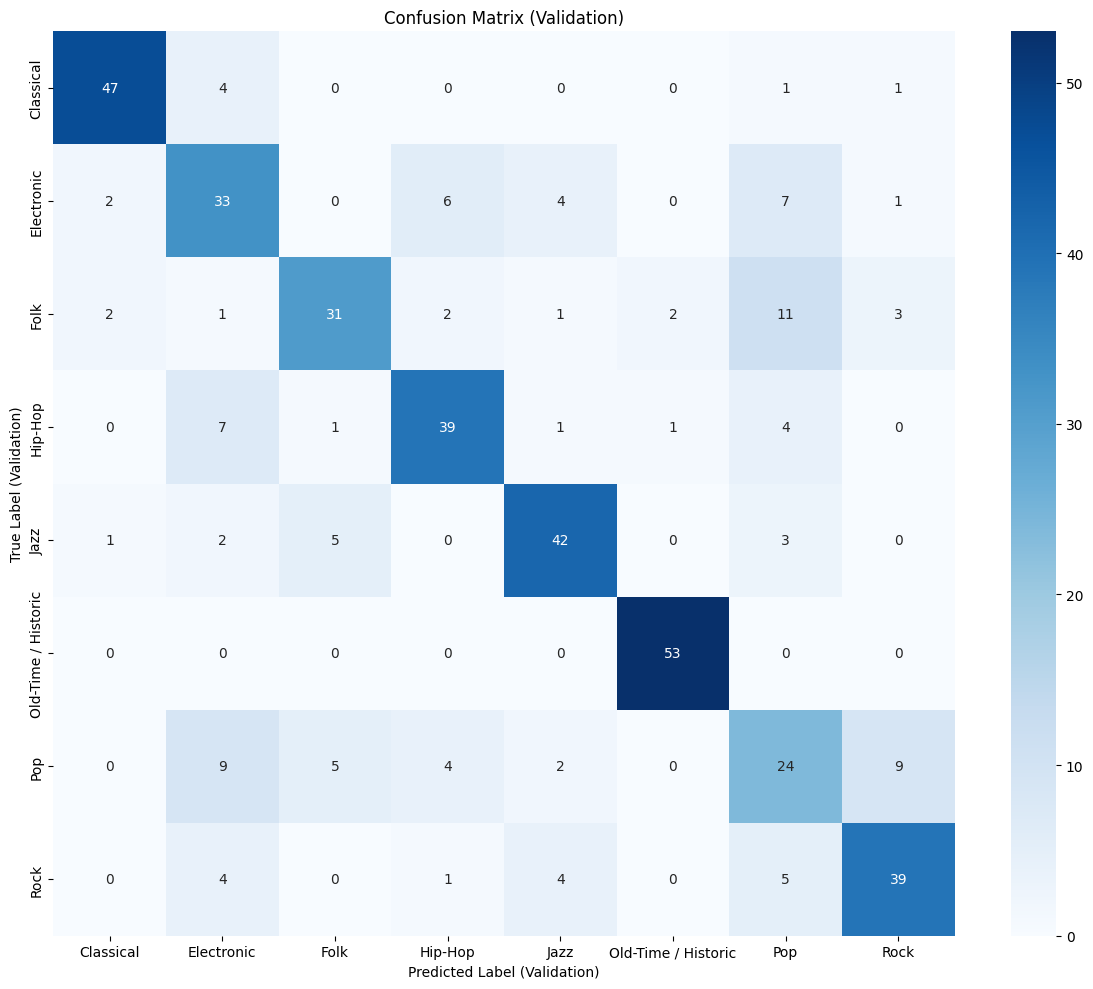


--- Test Evaluation ---
Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.85      0.87        53
         Electronic       0.67      0.74      0.70        53
               Folk       0.74      0.81      0.77        53
            Hip-Hop       0.89      0.77      0.83        53
               Jazz       0.79      0.79      0.79        53
Old-Time / Historic       0.93      1.00      0.96        53
                Pop       0.62      0.53      0.57        53
               Rock       0.75      0.81      0.78        53

           accuracy                           0.79       424
          macro avg       0.79      0.79      0.79       424
       weighted avg       0.79      0.79      0.79       424



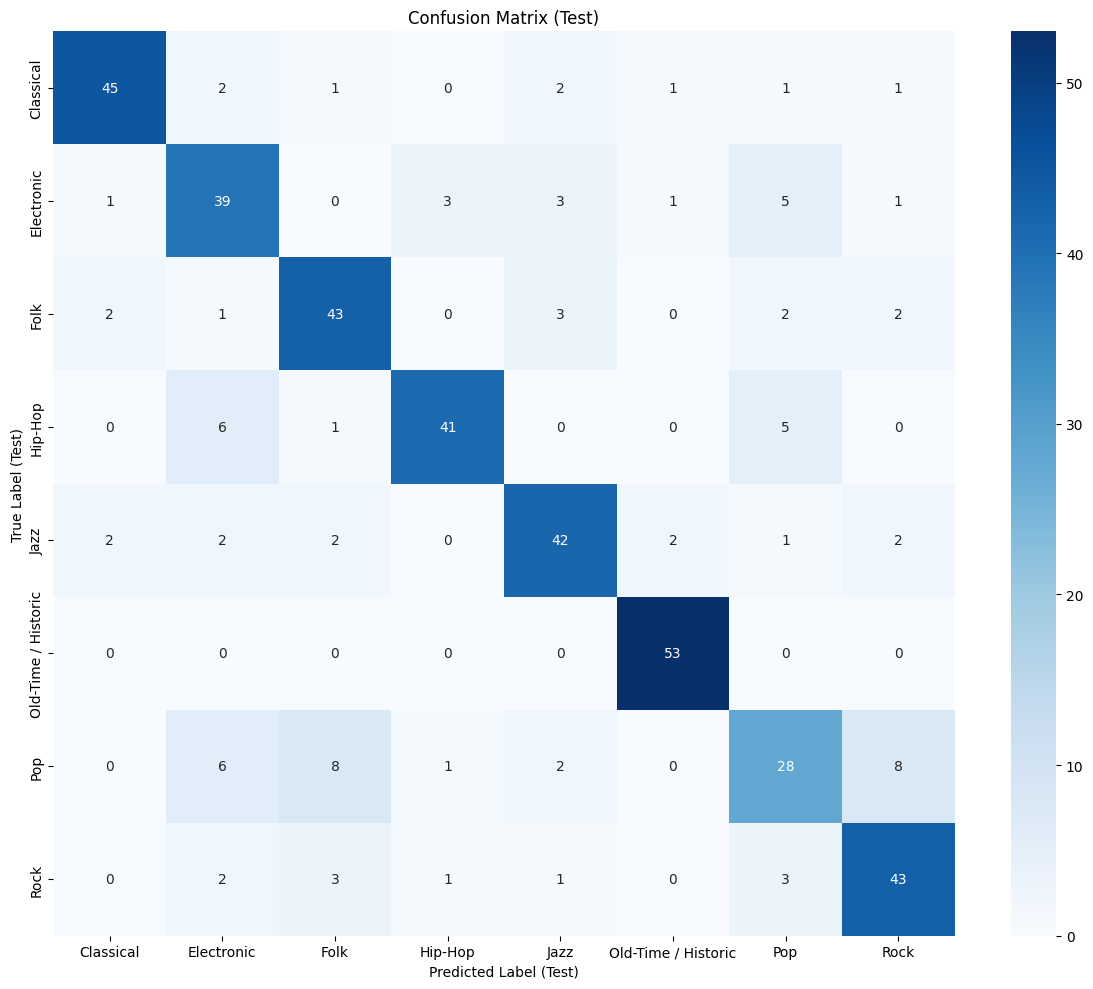

In [30]:
# Evaluate the model on the validation set
# Prints classification metrics (precision, recall, F1-score) and plots a confusion matrix
evaluate_model(model, val_loader, "Validation")

# Evaluate the model on the test set
# Same metrics and visualization but on unseen test data
evaluate_model(model, test_loader, "Test")

In [31]:
# ---------------------------------------------------------
# IDENTIFY MISCLASSIFIED TEST SAMPLES
# ---------------------------------------------------------
model.eval()

# Lists to store predictions, ground truth labels, and track IDs
all_preds = []
all_labels = []
all_track_ids = []

# Disable gradient computation for faster inference and lower memory usage
with torch.no_grad():
    # Iterate over test dataset batches
    for batch in test_loader:

        # Unpack batch data
        inputs, labels, track_ids = batch

        # Move tensors to the selected device (CPU or GPU)
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        # For HuggingFace-style models, outputs contain logits
        outputs = model(inputs)

        # Convert logits to predicted class indices
        preds = torch.argmax(outputs, dim=1)

        # Store predictions and labels (move back to CPU for numpy conversion)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Store track IDs for later analysis
        all_track_ids.extend(track_ids) 

# Convert lists to NumPy arrays for easier indexing
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

misclassified_idx = np.where(all_preds != all_labels)[0]

# Create a DataFrame containing only misclassified tracks
misclassified_tracks = pd.DataFrame({
    "track_id": np.array(all_track_ids)[misclassified_idx],

    # Convert integer labels back to genre names
    "true_genre": le.inverse_transform(all_labels[misclassified_idx]),
    "predicted_genre": le.inverse_transform(all_preds[misclassified_idx])
})

print(f"Anzahl Fehlklassifikationen: {len(misclassified_tracks)}")
print(misclassified_tracks.head())

# Optional: save to CSV
misclassified_tracks.to_csv(f"Results/{MODEL_NAME}_misclassified_tracks.csv",index=False)

Anzahl Fehlklassifikationen: 90
  track_id true_genre      predicted_genre
0    51939  Classical                  Pop
1    16420  Classical  Old-Time / Historic
2    73151  Classical                 Jazz
3    30131  Classical                 Jazz
4   148648  Classical           Electronic


In [32]:
# ============================================================
# MODEL-INPUT / SEGMENT-LEVEL AND TRACK-LEVEL EVALUATION
# ============================================================
# This evaluation block keeps the existing model-input evaluation and adds
# a track-level aggregation step. In the normal AST setup, one input usually
# corresponds to one complete track or one fixed crop. The aggregation code is
# still used here to keep the evaluation structure consistent with the 25 x 3s
# experiments.

from sklearn.metrics import accuracy_score, f1_score


def _get_logits(outputs):
    """
    Return logits for both possible model outputs:
    - plain tensor logits
    - dictionary with key 'logits'
    """
    if isinstance(outputs, dict):
        return outputs["logits"]
    return outputs


def collect_model_input_predictions(model, loader):
    """
    Run inference once and collect one row per model input.

    For the normal AST setup, this is usually equivalent to one row per track.
    The same structure is used as in the 25 x 3-second setup so that segment-
    level and track-level results are directly comparable across notebooks.

    Returns
    -------
    pandas.DataFrame
        Predictions with track_id, true label, predicted label and class
        probabilities for each model input.
    """
    model.eval()

    rows = []

    # Disable gradient computation for faster and memory-efficient inference
    with torch.no_grad():
        for inputs, labels, track_ids in loader:
            # Move data to the selected device
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            # AST expects input shape [batch, time, frequency]
            # Remove an additional channel dimension if one is present.
            if inputs.dim() == 4:
                inputs = inputs.squeeze(1)

            # Forward pass and conversion from logits to probabilities
            outputs = model(inputs)
            logits = _get_logits(outputs)
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            # Store one row per model input
            for track_id, true_label, pred_label, proba in zip(
                track_ids,
                labels.cpu().numpy(),
                predictions.cpu().numpy(),
                probabilities.cpu().numpy()
            ):
                rows.append({
                    "track_id": str(track_id),
                    "true_label": int(true_label),
                    "pred_label": int(pred_label),
                    "true_genre": le.inverse_transform([int(true_label)])[0],
                    "predicted_genre": le.inverse_transform([int(pred_label)])[0],
                    "probabilities": proba
                })

    return pd.DataFrame(rows)


def plot_confusion_matrix_from_labels(y_true, y_pred, title):
    """Plot a confusion matrix for the given labels."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def evaluate_model_input_predictions(input_df, set_name):
    """
    Evaluate predictions on the model-input level.

    For the normal AST setup, this can be identical or very close to track-level
    evaluation because each track often contributes only one model input. It is
    still reported separately for consistency with the 25 x 3-second experiments.
    """
    print(f"\n--- {set_name} MODEL-INPUT / SEGMENT-LEVEL EVALUATION ---")
    print("Accuracy:", accuracy_score(input_df["true_label"], input_df["pred_label"]))
    print("Macro-F1:", f1_score(input_df["true_label"], input_df["pred_label"], average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        input_df["true_label"],
        input_df["pred_label"],
        target_names=le.classes_
    ))

    plot_confusion_matrix_from_labels(
        input_df["true_label"],
        input_df["pred_label"],
        f"Confusion Matrix ({set_name}, Model-Input / Segment-Level)"
    )


def aggregate_predictions_to_track(input_df, method="mean_probability"):
    """
    Aggregate model-input predictions to one prediction per track.

    Parameters
    ----------
    input_df : pandas.DataFrame
        Output of collect_model_input_predictions().
    method : str
        'mean_probability' averages class probabilities per track.
        'majority_vote' uses the most frequent predicted class per track.

    Returns
    -------
    pandas.DataFrame
        One row per track with true label, predicted label, genre names and
        number of model inputs used for aggregation.
    """
    rows = []

    for track_id, group in input_df.groupby("track_id"):
        true_label = int(group["true_label"].iloc[0])

        if method == "mean_probability":
            # Average class probabilities over all inputs belonging to one track
            prob_matrix = np.stack(group["probabilities"].values)
            mean_probs = prob_matrix.mean(axis=0)
            pred_label = int(np.argmax(mean_probs))

        elif method == "majority_vote":
            # Use the most frequently predicted class over all inputs of the track
            pred_label = int(group["pred_label"].value_counts().idxmax())

        else:
            raise ValueError("method must be either 'mean_probability' or 'majority_vote'")

        rows.append({
            "track_id": track_id,
            "true_label": true_label,
            "pred_label": pred_label,
            "true_genre": le.inverse_transform([true_label])[0],
            "predicted_genre": le.inverse_transform([pred_label])[0],
            "n_segments": len(group),
            "aggregation_method": method
        })

    return pd.DataFrame(rows)


def evaluate_track_predictions(track_df, set_name, method):
    """Evaluate one prediction per track after aggregation."""
    print(f"\n--- {set_name} TRACK-LEVEL EVALUATION ({method}) ---")
    print("Accuracy:", accuracy_score(track_df["true_label"], track_df["pred_label"]))
    print("Macro-F1:", f1_score(track_df["true_label"], track_df["pred_label"], average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        track_df["true_label"],
        track_df["pred_label"],
        target_names=le.classes_
    ))

    plot_confusion_matrix_from_labels(
        track_df["true_label"],
        track_df["pred_label"],
        f"Confusion Matrix ({set_name}, Track-Level, {method})"
    )



--- Validation MODEL-INPUT / SEGMENT-LEVEL EVALUATION ---
Accuracy: 0.7264150943396226
Macro-F1: 0.7265768634678935

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.89      0.90        53
         Electronic       0.55      0.62      0.58        53
               Folk       0.74      0.58      0.65        53
            Hip-Hop       0.75      0.74      0.74        53
               Jazz       0.78      0.79      0.79        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.44      0.45      0.44        53
               Rock       0.74      0.74      0.74        53

           accuracy                           0.73       424
          macro avg       0.73      0.73      0.73       424
       weighted avg       0.73      0.73      0.73       424



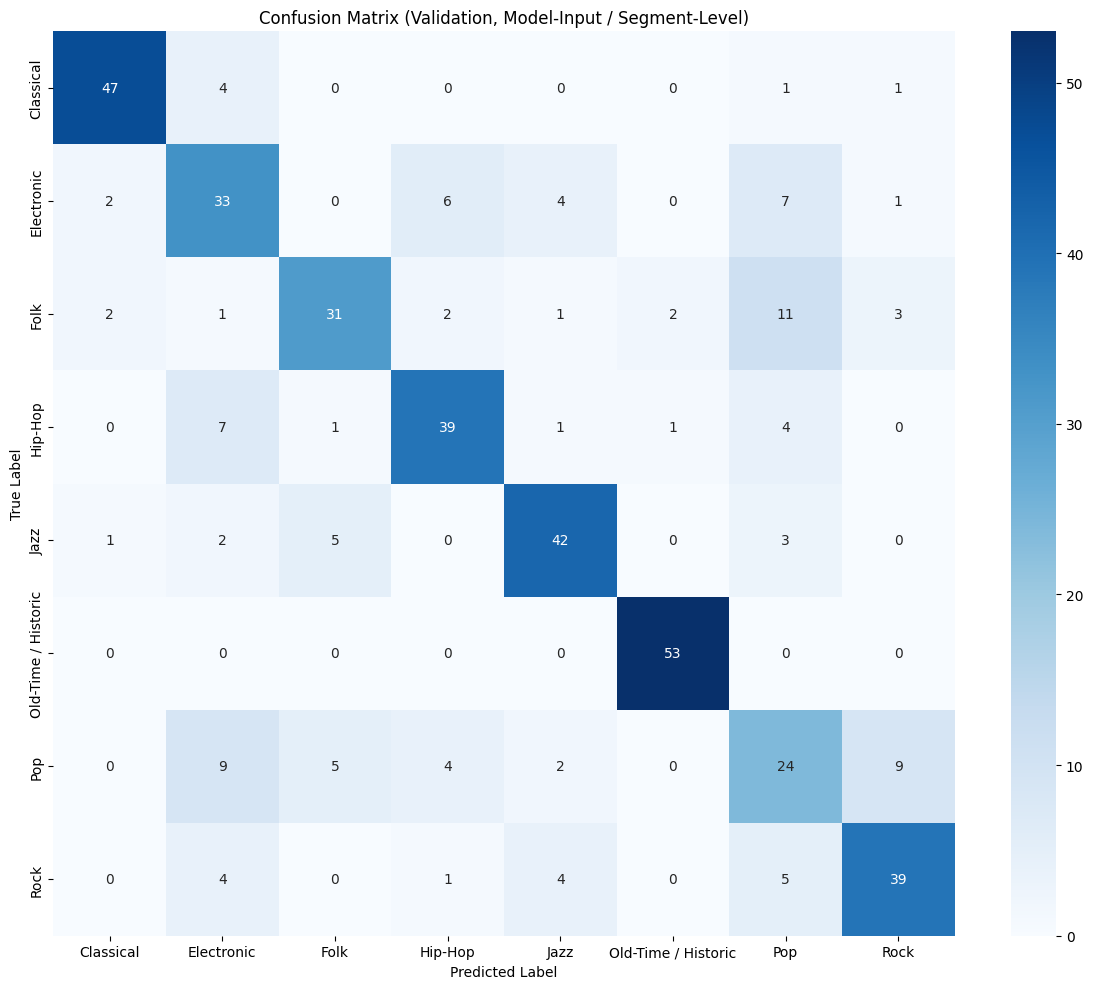


--- Validation TRACK-LEVEL EVALUATION (mean_probability) ---
Accuracy: 0.7264150943396226
Macro-F1: 0.7265768634678935

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.89      0.90        53
         Electronic       0.55      0.62      0.58        53
               Folk       0.74      0.58      0.65        53
            Hip-Hop       0.75      0.74      0.74        53
               Jazz       0.78      0.79      0.79        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.44      0.45      0.44        53
               Rock       0.74      0.74      0.74        53

           accuracy                           0.73       424
          macro avg       0.73      0.73      0.73       424
       weighted avg       0.73      0.73      0.73       424



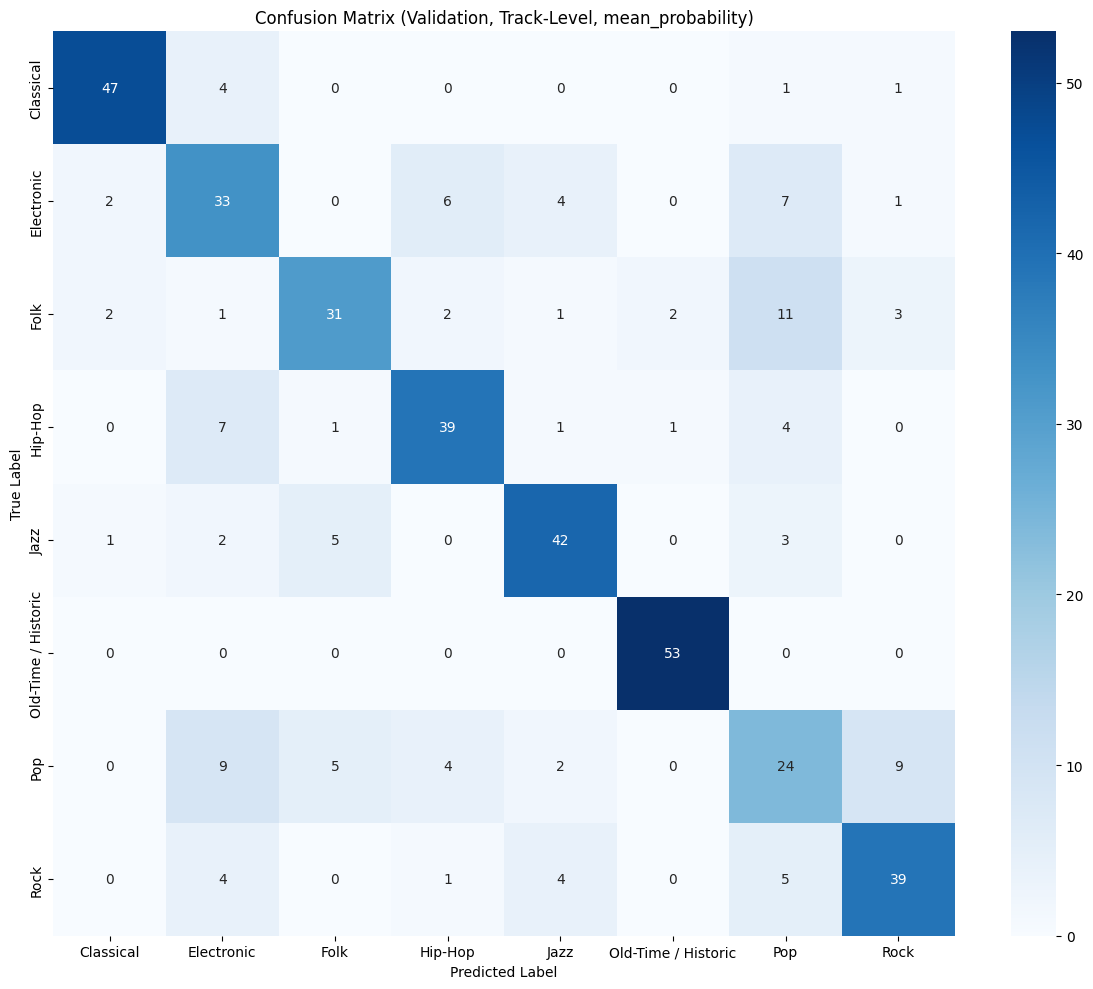


--- Validation TRACK-LEVEL EVALUATION (majority_vote) ---
Accuracy: 0.7264150943396226
Macro-F1: 0.7265768634678935

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.89      0.90        53
         Electronic       0.55      0.62      0.58        53
               Folk       0.74      0.58      0.65        53
            Hip-Hop       0.75      0.74      0.74        53
               Jazz       0.78      0.79      0.79        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.44      0.45      0.44        53
               Rock       0.74      0.74      0.74        53

           accuracy                           0.73       424
          macro avg       0.73      0.73      0.73       424
       weighted avg       0.73      0.73      0.73       424



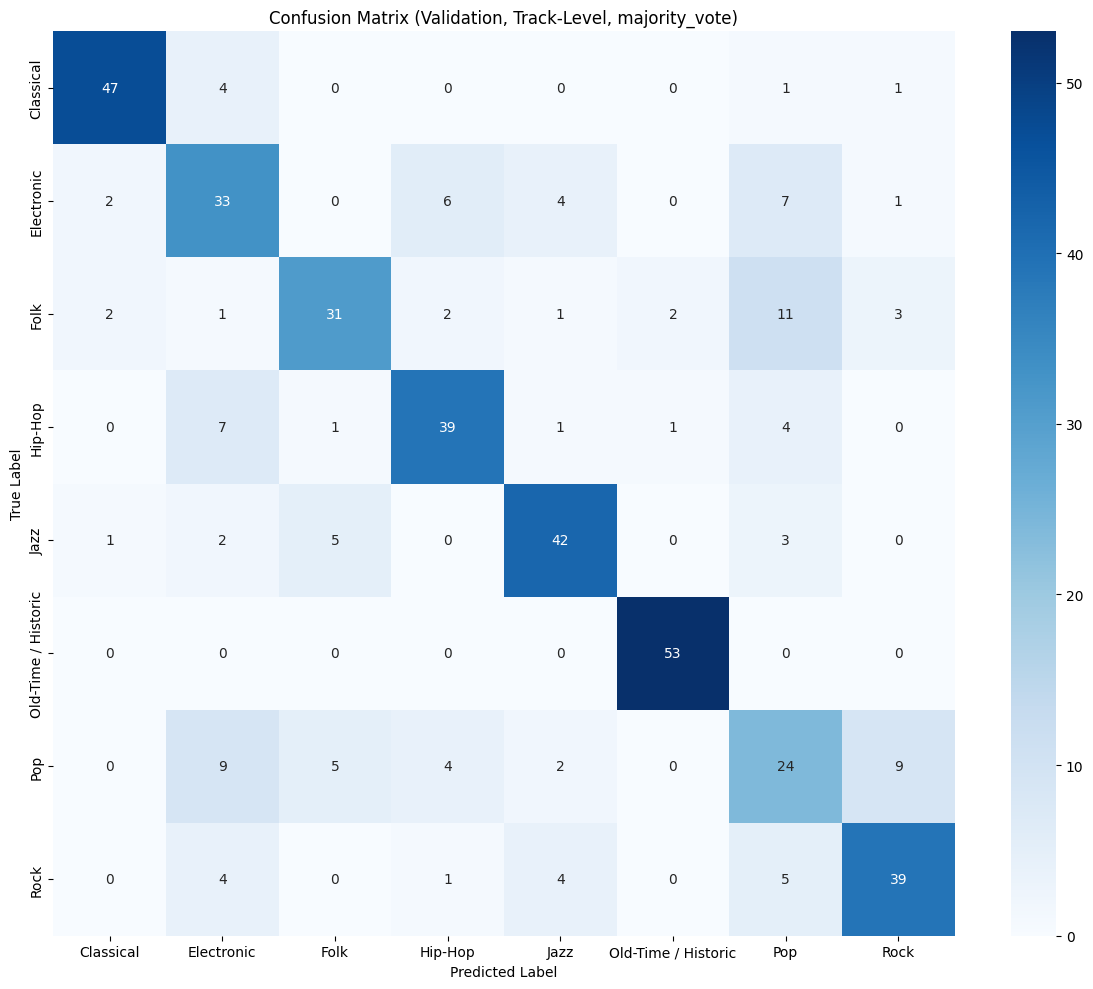


--- Test MODEL-INPUT / SEGMENT-LEVEL EVALUATION ---
Accuracy: 0.7877358490566038
Macro-F1: 0.7861103325748866

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.85      0.87        53
         Electronic       0.67      0.74      0.70        53
               Folk       0.74      0.81      0.77        53
            Hip-Hop       0.89      0.77      0.83        53
               Jazz       0.79      0.79      0.79        53
Old-Time / Historic       0.93      1.00      0.96        53
                Pop       0.62      0.53      0.57        53
               Rock       0.75      0.81      0.78        53

           accuracy                           0.79       424
          macro avg       0.79      0.79      0.79       424
       weighted avg       0.79      0.79      0.79       424



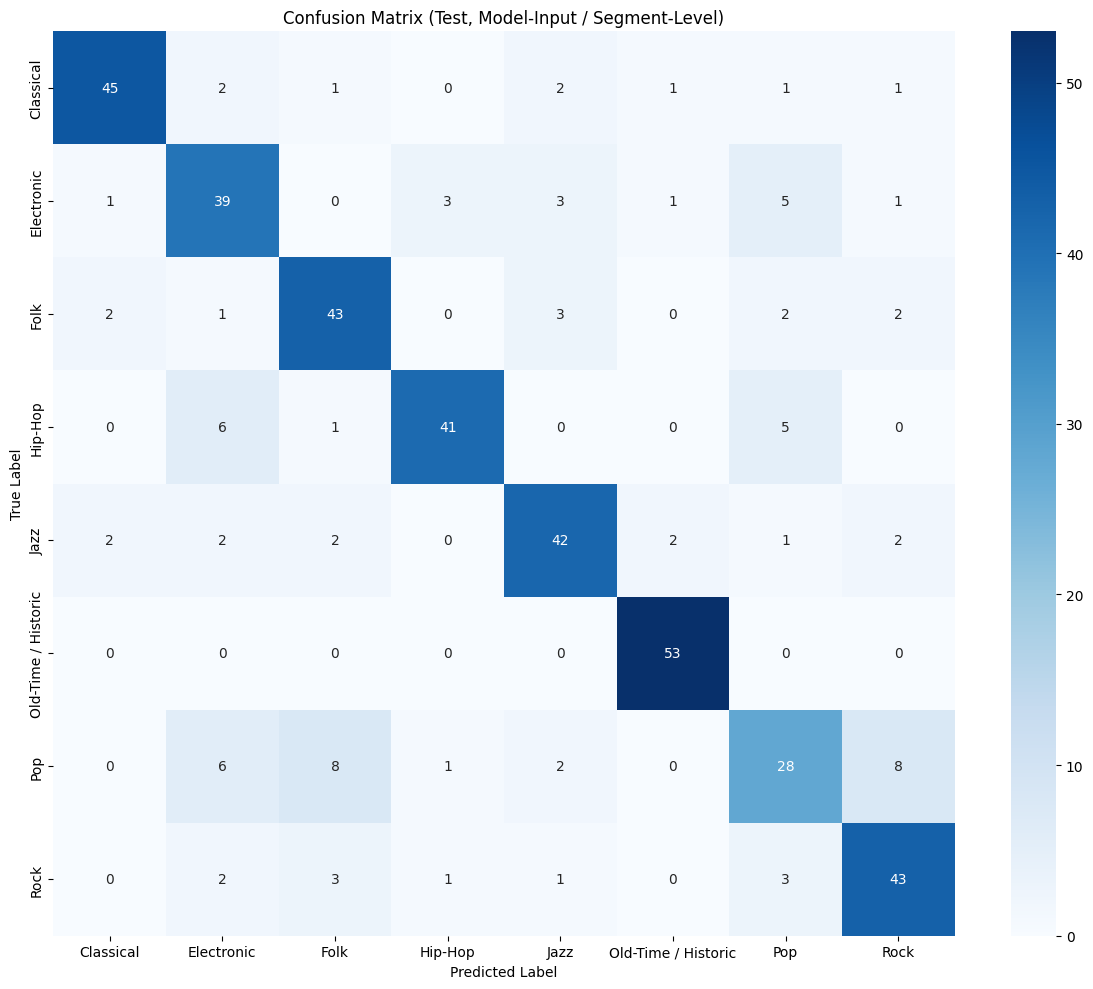


--- Test TRACK-LEVEL EVALUATION (mean_probability) ---
Accuracy: 0.7877358490566038
Macro-F1: 0.7861103325748866

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.85      0.87        53
         Electronic       0.67      0.74      0.70        53
               Folk       0.74      0.81      0.77        53
            Hip-Hop       0.89      0.77      0.83        53
               Jazz       0.79      0.79      0.79        53
Old-Time / Historic       0.93      1.00      0.96        53
                Pop       0.62      0.53      0.57        53
               Rock       0.75      0.81      0.78        53

           accuracy                           0.79       424
          macro avg       0.79      0.79      0.79       424
       weighted avg       0.79      0.79      0.79       424



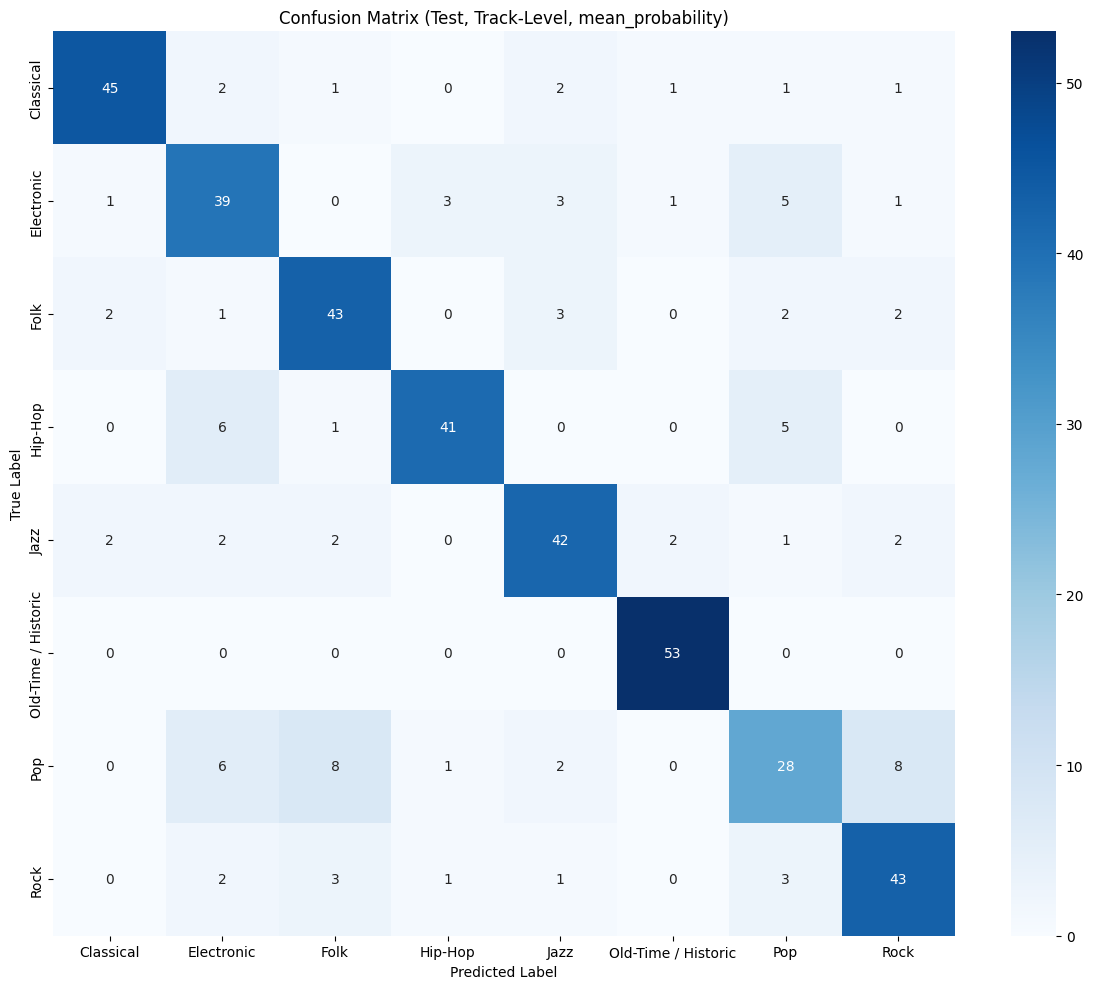


--- Test TRACK-LEVEL EVALUATION (majority_vote) ---
Accuracy: 0.7877358490566038
Macro-F1: 0.7861103325748866

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.90      0.85      0.87        53
         Electronic       0.67      0.74      0.70        53
               Folk       0.74      0.81      0.77        53
            Hip-Hop       0.89      0.77      0.83        53
               Jazz       0.79      0.79      0.79        53
Old-Time / Historic       0.93      1.00      0.96        53
                Pop       0.62      0.53      0.57        53
               Rock       0.75      0.81      0.78        53

           accuracy                           0.79       424
          macro avg       0.79      0.79      0.79       424
       weighted avg       0.79      0.79      0.79       424



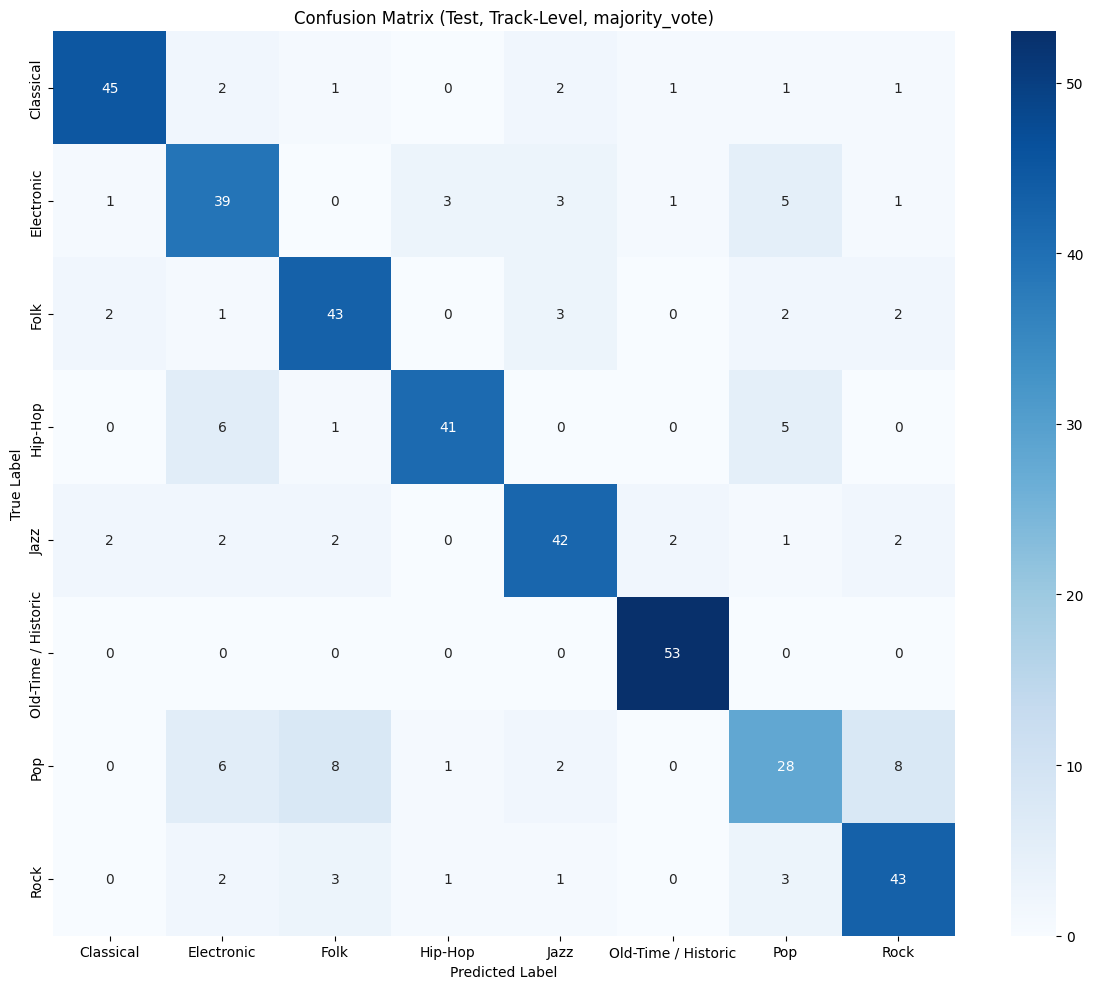

In [33]:
# ============================================================
# RUN MODEL-INPUT / SEGMENT-LEVEL AND TRACK-LEVEL EVALUATION
# ============================================================

# Validation set
val_input_df = collect_model_input_predictions(model, val_loader)
evaluate_model_input_predictions(val_input_df, "Validation")

val_track_mean_df = aggregate_predictions_to_track(val_input_df, method="mean_probability")
evaluate_track_predictions(val_track_mean_df, "Validation", method="mean_probability")

val_track_vote_df = aggregate_predictions_to_track(val_input_df, method="majority_vote")
evaluate_track_predictions(val_track_vote_df, "Validation", method="majority_vote")


# Test set
test_input_df = collect_model_input_predictions(model, test_loader)
evaluate_model_input_predictions(test_input_df, "Test")

test_track_mean_df = aggregate_predictions_to_track(test_input_df, method="mean_probability")
evaluate_track_predictions(test_track_mean_df, "Test", method="mean_probability")

test_track_vote_df = aggregate_predictions_to_track(test_input_df, method="majority_vote")
evaluate_track_predictions(test_track_vote_df, "Test", method="majority_vote")


In [ ]:
# ============================================================
# SAVE TRACK-LEVEL RESULTS AND MISCLASSIFICATIONS
# ============================================================
# This saves the track-level predictions and misclassifications for both
# aggregation strategies. For the normal AST setup, n_segments is often 1,
# but the export format is kept consistent with the 25 x 3-second notebooks.

if "test_input_df" not in globals():
    test_input_df = collect_model_input_predictions(model, test_loader)

if "test_track_mean_df" not in globals():
    test_track_mean_df = aggregate_predictions_to_track(
        test_input_df,
        method="mean_probability"
    )

if "test_track_vote_df" not in globals():
    test_track_vote_df = aggregate_predictions_to_track(
        test_input_df,
        method="majority_vote"
    )

# Select only wrongly classified tracks for error analysis
misclassified_tracks_mean = test_track_mean_df[
    test_track_mean_df["true_label"] != test_track_mean_df["pred_label"]
].copy()

misclassified_tracks_vote = test_track_vote_df[
    test_track_vote_df["true_label"] != test_track_vote_df["pred_label"]
].copy()

print(f"Number of misclassified tracks (mean probability): {len(misclassified_tracks_mean)}")
print(misclassified_tracks_mean[["track_id", "true_genre", "predicted_genre", "n_segments"]].head())

print(f"Number of misclassified tracks (majority vote): {len(misclassified_tracks_vote)}")
print(misclassified_tracks_vote[["track_id", "true_genre", "predicted_genre", "n_segments"]].head())

# Create result directory if it does not exist
results_dir = MODEL_RESULTS_DIR
os.makedirs(results_dir, exist_ok=True)

# Save all test predictions on the model-input level.
test_input_df.to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_test_predictions_model_input_level.csv"),
    index=False
)

# Save all track-level test predictions for later analysis.
test_track_mean_df.to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_test_predictions_track_level_mean_probability.csv"),
    index=False
)

test_track_vote_df.to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_test_predictions_track_level_majority_vote.csv"),
    index=False
)

# Save only misclassified tracks for error analysis.
misclassified_tracks_mean[[
    "track_id",
    "true_genre",
    "predicted_genre",
    "n_segments",
    "aggregation_method"
]].to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_misclassified_tracks_track_level_mean_probability.csv"),
    index=False
)

misclassified_tracks_vote[[
    "track_id",
    "true_genre",
    "predicted_genre",
    "n_segments",
    "aggregation_method"
]].to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_misclassified_tracks_track_level_majority_vote.csv"),
    index=False
)


Number of misclassified tracks (mean probability): 90
   track_id true_genre      predicted_genre  n_segments
9      1064       Jazz                 Rock           1
19   109683    Hip-Hop                  Pop           1
20    10975       Jazz  Old-Time / Historic           1
24   110750    Hip-Hop           Electronic           1
27   111378        Pop                 Rock           1
Number of misclassified tracks (majority vote): 90
   track_id true_genre      predicted_genre  n_segments
9      1064       Jazz                 Rock           1
19   109683    Hip-Hop                  Pop           1
20    10975       Jazz  Old-Time / Historic           1
24   110750    Hip-Hop           Electronic           1
27   111378        Pop                 Rock           1
